# Clustering Assignment
#Theoritical questions

Q1. What is unsupervised learning in the context of machine learning?  
Ans:- It is a type of learning where the model finds hidden patterns or groupings in unlabeled data without predefined output.

----------------------------------------------------------------------------------------------------------------------------------------------
Q2. How does K-Means clustering algorithm work?  
Ans:- It partitions data into 𝑘 clusters by iteratively assigning points to the nearest centroid and updating centroids until convergence.

----------------------------------------------------------------------------------------------------------------------------------------------
Q3. Explain the concept of a dendrogram in hierarchical clustering.  
Ans:- A dendrogram is a tree-like diagram that shows the arrangement of clusters formed at each step of hierarchical clustering.

----------------------------------------------------------------------------------------------------------------------------------------------
Q4. What is the main difference between K-Means and Hierarchical Clustering?  
Ans:- K-Means requires the number of clusters in advance and is centroid-based, while hierarchical clustering builds nested clusters without needing 𝑘upfront.

----------------------------------------------------------------------------------------------------------------------------------------------
Q5. What are the advantages of DBSCAN over K-Means?  
Ans:- DBSCAN can find clusters of arbitrary shape, does not require specifying the number of clusters, and can detect noise/outliers.

----------------------------------------------------------------------------------------------------------------------------------------------
Q6. When would you use Silhouette Score in clustering?  
Ans:- To evaluate clustering quality by measuring how similar a point is to its own cluster compared to other clusters.

----------------------------------------------------------------------------------------------------------------------------------------------
Q7. What are the limitations of Hierarchical Clustering?  
Ans: High computational cost for large datasets, sensitivity to noise/outliers, and difficulty in undoing early wrong merges.

----------------------------------------------------------------------------------------------------------------------------------------------
Q8. Why is feature scaling important in clustering algorithms like K-Means?  
Ans:- Because K-Means uses distance metrics; unscaled features can dominate clustering results.

----------------------------------------------------------------------------------------------------------------------------------------------
Q9. How does DBSCAN identify noise points?  
Ans:- Points not belonging to any cluster (i.e., not within MinPts of a dense region) are labeled as noise.

----------------------------------------------------------------------------------------------------------------------------------------------
Q10. Define inertia in the context of K-Means.  
Ans:- Inertia is the sum of squared distances between data points and their assigned cluster centroids; lower inertia indicates better fit.

----------------------------------------------------------------------------------------------------------------------------------------------
Q11. What is the elbow method in K-Means clustering?  
Ans:- A technique to determine optimal 𝑘 by plotting inertia vs. 𝑘 and finding the “elbow” point where inertia reduction slows.

----------------------------------------------------------------------------------------------------------------------------------------------
Q12. Describe the concept of "density" in DBSCAN.  
Ans:- Density is defined by the number of points within a radius (𝜀); dense regions form clusters.

----------------------------------------------------------------------------------------------------------------------------------------------
Q13. Can hierarchical clustering be used on categorical data?  
Ans:- Yes, but it requires appropriate distance measures (e.g., Hamming distance) instead of Euclidean.

----------------------------------------------------------------------------------------------------------------------------------------------
Q14. What does a negative Silhouette Score indicate?  
Ans:- The point is likely misclassified, being closer to another cluster than its own.

----------------------------------------------------------------------------------------------------------------------------------------------
Q15. Explain the term "linkage criteria" in hierarchical clustering.  
Ans:- It defines how distances between clusters are computed (e.g., single, complete, average linkage).

----------------------------------------------------------------------------------------------------------------------------------------------
Q16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?  
Ans:- Because it assumes clusters are spherical and equally sized, leading to misclassification in uneven distributions.

----------------------------------------------------------------------------------------------------------------------------------------------
Q17. What are the core parameters in DBSCAN, and how do they influence clustering?  
Ans:-𝜀: radius for neighborhood search
MinPts: minimum points to form a dense region Together, they control cluster formation and noise detection.

----------------------------------------------------------------------------------------------------------------------------------------------
Q18. How does K-Means++ improve upon standard K-Means initialization?  
Ans:- It selects initial centroids more strategically to spread them out, reducing chances of poor clustering.

----------------------------------------------------------------------------------------------------------------------------------------------
Q19. What is agglomerative clustering?  
Ans:- A bottom-up hierarchical method where each point starts as its own cluster and merges iteratively until one cluster remains.

----------------------------------------------------------------------------------------------------------------------------------------------
Q20. What makes Silhouette Score a better metric than just inertia for model evaluation?  
Ans:- Silhouette Score considers both cohesion (within-cluster similarity) and separation (between-cluster difference), while inertia only measures cohesion.

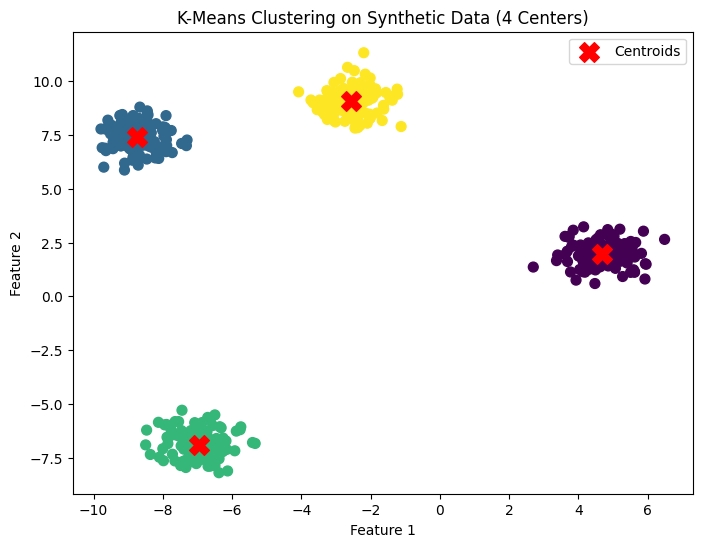

In [1]:
#Practical questions
#Q.21)Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot
#Ans:-
# Synthetic Data with K-Means Clustering
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic dataset with 4 centers
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Visualize clusters
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering on Synthetic Data (4 Centers)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [2]:
#Q.22)Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels
#Ans:-
# Agglomerative Clustering on Iris dataset

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Iris dataset
iris = load_iris()
X = iris.data

# Step 2: Apply Agglomerative Clustering with 3 clusters
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(X)

# Step 3: Display first 10 predicted labels
print("First 10 predicted cluster labels:", labels[:10])


First 10 predicted cluster labels: [1 1 1 1 1 1 1 1 1 1]


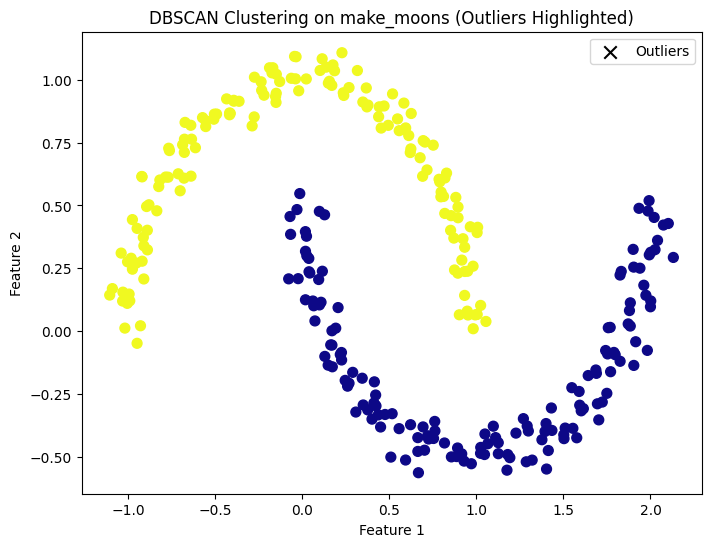

In [3]:
#Q.23)Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot
#Ans:-
# DBSCAN on make_moons synthetic dataset

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Step 1: Generate synthetic dataset
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))

# Plot clusters (excluding noise)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=50)

# Highlight outliers (label = -1)
outliers = labels == -1
plt.scatter(X[outliers, 0], X[outliers, 1], c='black', s=80, marker='x', label='Outliers')

plt.title("DBSCAN Clustering on make_moons (Outliers Highlighted)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [4]:
#Q.24)Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster
#Ans:-
# K-Means clustering on Wine dataset with standardized features

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply K-Means clustering (let's assume 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Step 4: Print size of each cluster
unique, counts = np.unique(labels, return_counts=True)
cluster_sizes = dict(zip(unique, counts))

print("Cluster sizes:", cluster_sizes)

Cluster sizes: {np.int32(0): np.int64(65), np.int32(1): np.int64(51), np.int32(2): np.int64(62)}


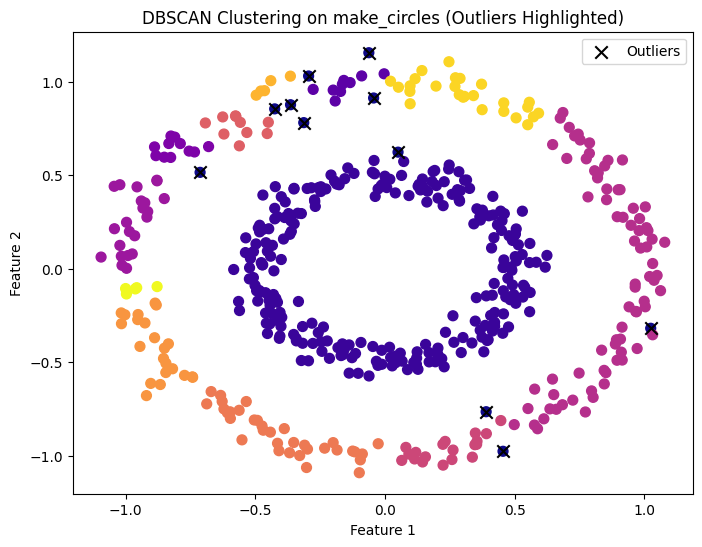

In [5]:
#Q.25)Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result
#Ans:-
# DBSCAN clustering on make_circles dataset

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

# Step 1: Generate synthetic dataset
X, y_true = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.1, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))

# Plot clusters (excluding noise)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=50)

# Highlight outliers (label = -1)
outliers = labels == -1
plt.scatter(X[outliers, 0], X[outliers, 1], c='black', s=80, marker='x', label='Outliers')

plt.title("DBSCAN Clustering on make_circles (Outliers Highlighted)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [6]:
#Q.26)Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids
#Ans:-
# K-Means clustering on Breast Cancer dataset with MinMaxScaler

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

# Step 1: Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Step 2: Apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply K-Means clustering with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

# Step 4: Output cluster centroids
print("Cluster centroids:\n", kmeans.cluster_centers_)


Cluster centroids:
 [[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


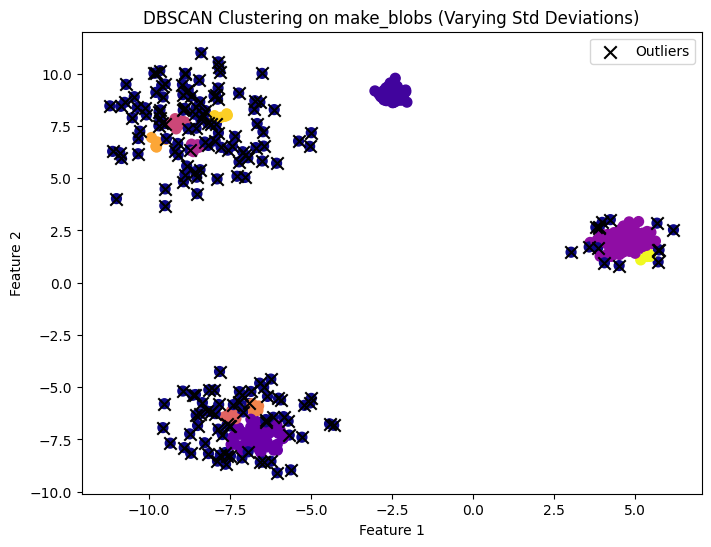

In [7]:
#Q.27)Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN
#Ans:-
# DBSCAN clustering on make_blobs dataset with varying std deviations

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

# Step 1: Generate synthetic dataset with varying cluster standard deviations
X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=[0.2, 0.5, 1.0, 1.5],  # different spreads for each cluster
    random_state=42
)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))

# Plot clusters (excluding noise)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=50)

# Highlight outliers (label = -1)
outliers = labels == -1
plt.scatter(X[outliers, 0], X[outliers, 1], c='black', s=80, marker='x', label='Outliers')

plt.title("DBSCAN Clustering on make_blobs (Varying Std Deviations)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

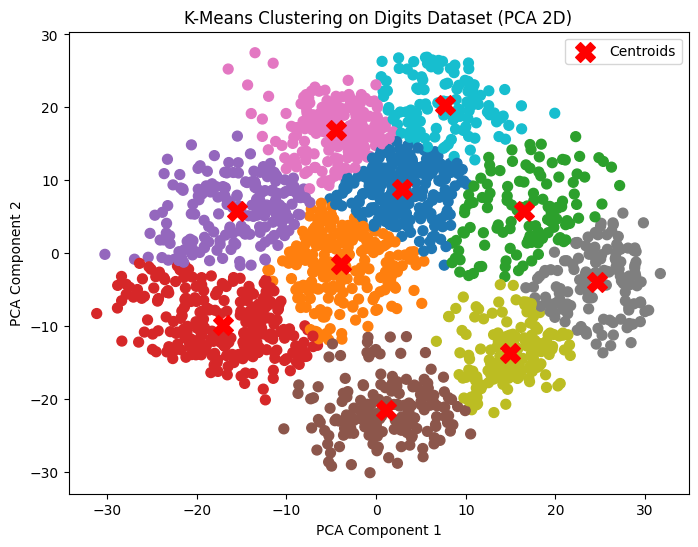

In [8]:
#Q.28)Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means
#Ans:-
# K-Means clustering on Digits dataset with PCA visualization

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Step 1: Load Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 3: Apply K-Means clustering (let’s assume 10 clusters for digits 0–9)
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Step 4: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering on Digits Dataset (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

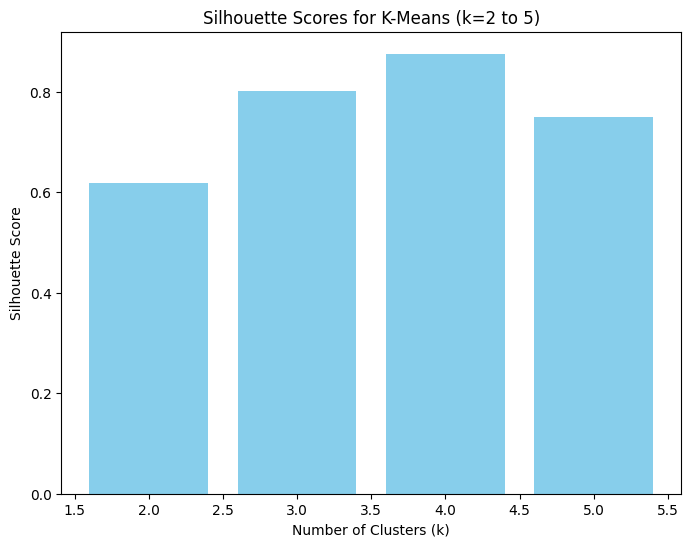

Silhouette Scores: {2: 0.6187443348087857, 3: 0.802137610814018, 4: 0.8757323158768271, 5: 0.7495917971422745}


In [9]:
#Q.29)Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart
#Ans:-
# Silhouette Score evaluation for K-Means clustering

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 1: Generate synthetic dataset
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

# Step 2: Evaluate silhouette scores for k = 2 to 5
scores = {}
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores[k] = score

# Step 3: Plot silhouette scores as bar chart
plt.figure(figsize=(8,6))
plt.bar(scores.keys(), scores.values(), color='skyblue')
plt.title("Silhouette Scores for K-Means (k=2 to 5)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Step 4: Print scores for reference
print("Silhouette Scores:", scores)

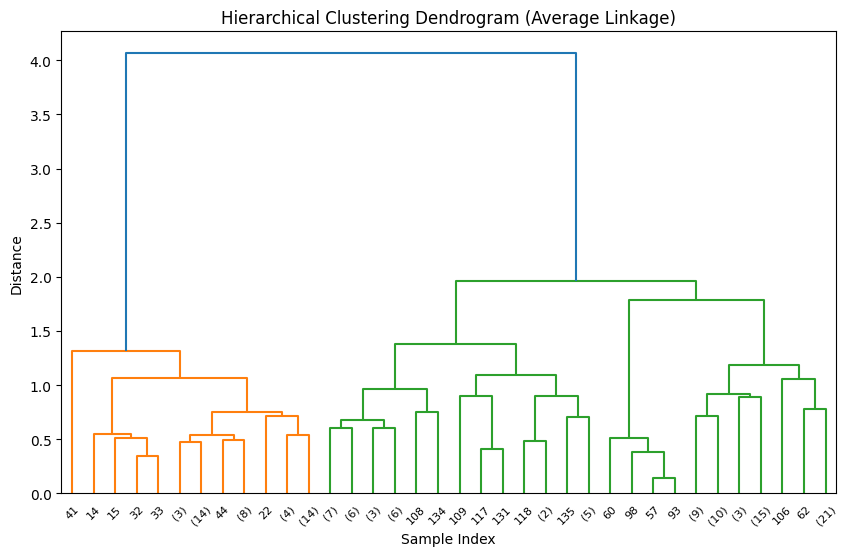

In [10]:
#Q.30)Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage
#Ans:-
# Hierarchical Clustering with Dendrogram on Iris dataset

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import linkage, dendrogram

# Step 1: Load Iris dataset
iris = load_iris()
X = iris.data

# Step 2: Perform hierarchical clustering with average linkage
Z = linkage(X, method='average')

# Step 3: Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode='level', p=5)  # truncate for readability
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()

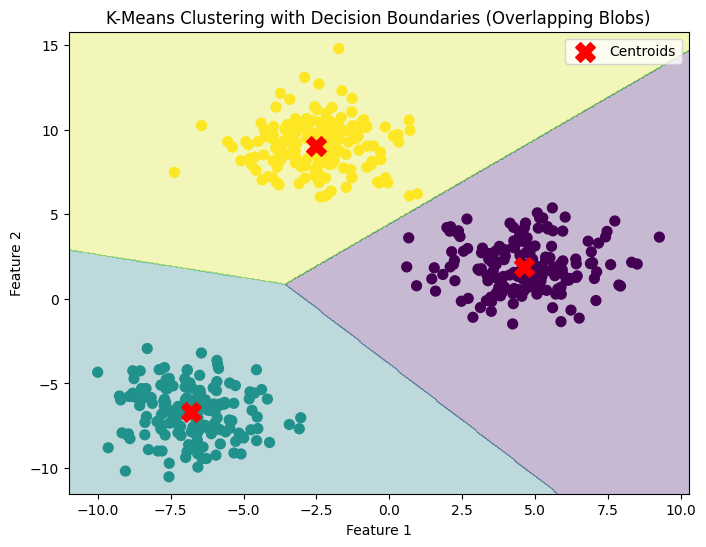

In [11]:
#Q.31)Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries
#Ans:-
# K-Means clustering with decision boundaries on overlapping blobs

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import numpy as np

# Step 1: Generate synthetic dataset with overlapping clusters
X, y_true = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=[1.5, 1.5, 1.5],  # larger std → overlapping clusters
    random_state=42
)

# Step 2: Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Step 3: Create mesh grid for decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Step 4: Visualization
plt.figure(figsize=(8,6))

# Plot decision boundaries
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering with Decision Boundaries (Overlapping Blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

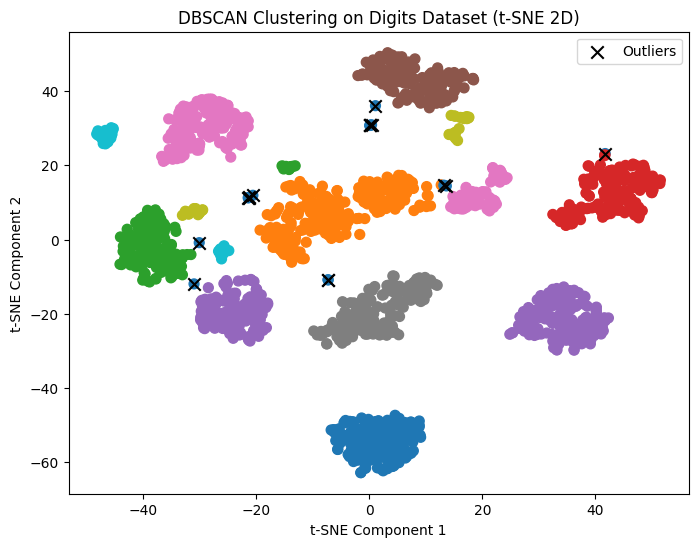

In [12]:
#Q.32)Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results
#Ans:-
# DBSCAN clustering on Digits dataset with t-SNE visualization

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN

# Step 1: Load Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)  # eps tuned for t-SNE scale
labels = dbscan.fit_predict(X_tsne)

# Step 4: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=50)

# Highlight outliers (label = -1)
outliers = labels == -1
plt.scatter(X_tsne[outliers, 0], X_tsne[outliers, 1], 
            c='black', s=80, marker='x', label='Outliers')

plt.title("DBSCAN Clustering on Digits Dataset (t-SNE 2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.show()

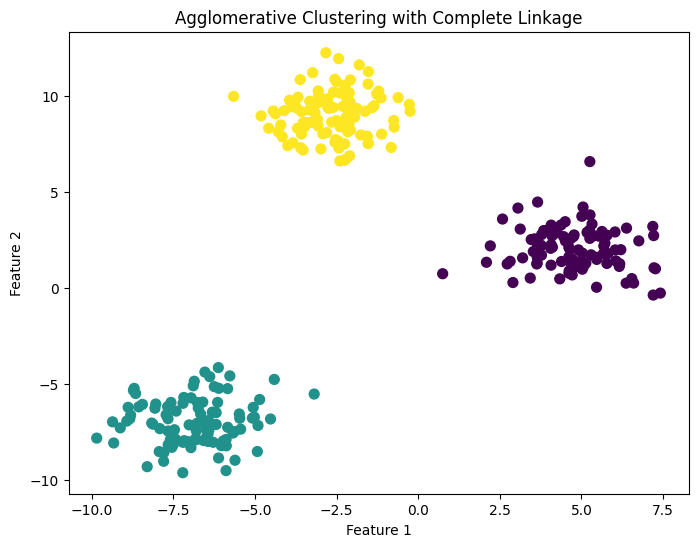

In [13]:
#Q.33)Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result
#Ans:-
# Agglomerative Clustering with complete linkage on synthetic blobs

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# Step 1: Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)

# Step 2: Apply Agglomerative Clustering with complete linkage
agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = agg.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

plt.title("Agglomerative Clustering with Complete Linkage")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

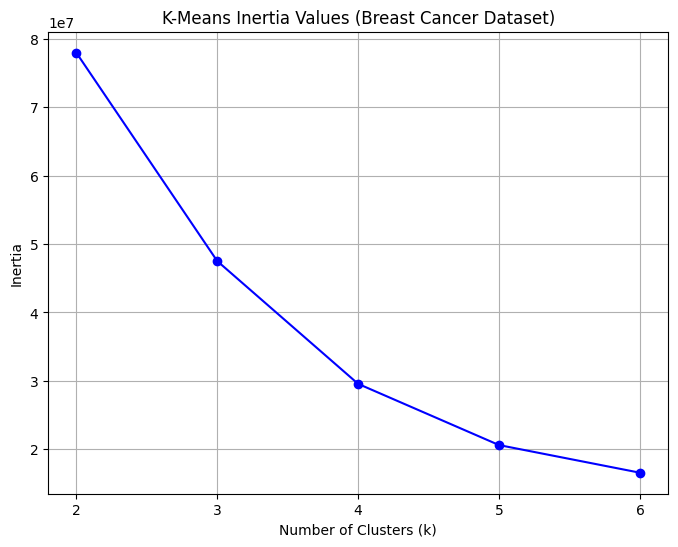

k = 2, Inertia = 77943099.88
k = 3, Inertia = 47499852.23
k = 4, Inertia = 29555736.33
k = 5, Inertia = 20612895.82
k = 6, Inertia = 16573867.02


In [14]:
#Q.34)Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot
#Ans:-
# Compare inertia values for K-Means clustering on Breast Cancer dataset

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans

# Step 1: Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Step 2: Compute inertia values for K = 2 to 6
inertias = []
K_values = range(2, 7)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Step 3: Plot inertia values
plt.figure(figsize=(8,6))
plt.plot(K_values, inertias, marker='o', linestyle='-', color='blue')
plt.title("K-Means Inertia Values (Breast Cancer Dataset)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(K_values)
plt.grid(True)
plt.show()

# Step 4: Print inertia values for reference
for k, inertia in zip(K_values, inertias):
    print(f"k = {k}, Inertia = {inertia:.2f}")

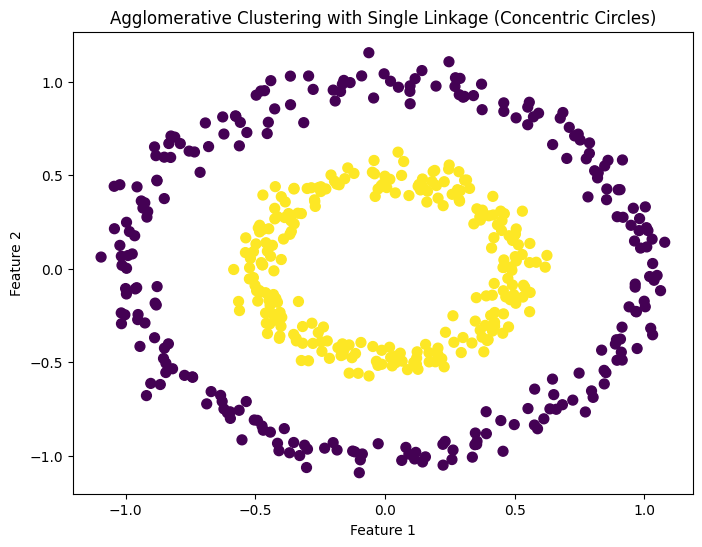

In [15]:
#Q.35)Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage
#Ans:-
# Agglomerative Clustering with single linkage on concentric circles

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

# Step 1: Generate synthetic concentric circles dataset
X, y_true = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Step 2: Apply Agglomerative Clustering with single linkage
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agg.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

plt.title("Agglomerative Clustering with Single Linkage (Concentric Circles)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [16]:
#Q.36)Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise)
#Ans:-
# DBSCAN clustering on Wine dataset after scaling

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)  # eps tuned for Wine dataset
labels = dbscan.fit_predict(X_scaled)

# Step 4: Count clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters (excluding noise):", n_clusters)

Number of clusters (excluding noise): 0


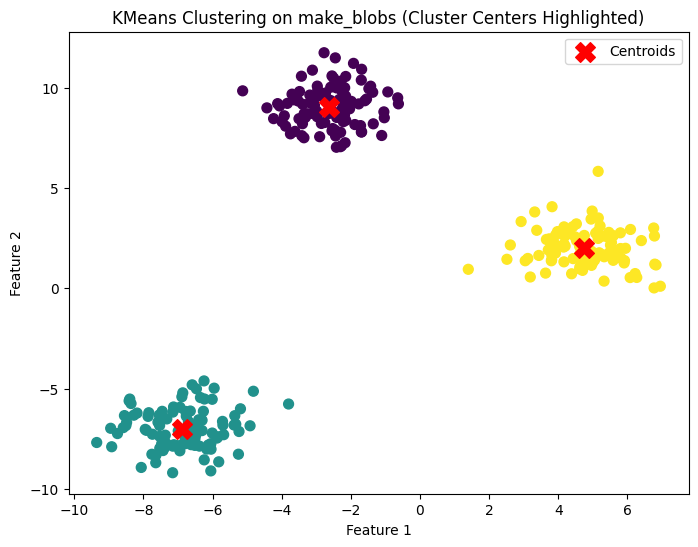

In [17]:
#Q.37)Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points
#Ans:-
# KMeans clustering with cluster centers on synthetic blobs

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))

# Plot data points colored by cluster
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("KMeans Clustering on make_blobs (Cluster Centers Highlighted)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [18]:
#Q.38)Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise
#Ans:-
# DBSCAN clustering on Iris dataset

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Load Iris dataset
iris = load_iris()
X = iris.data

# Step 2: Scale the data (important for DBSCAN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)  # eps tuned for Iris dataset
labels = dbscan.fit_predict(X_scaled)

# Step 4: Count noise samples (label = -1)
n_noise = np.sum(labels == -1)

print("Number of noise samples:", n_noise)

Number of noise samples: 26


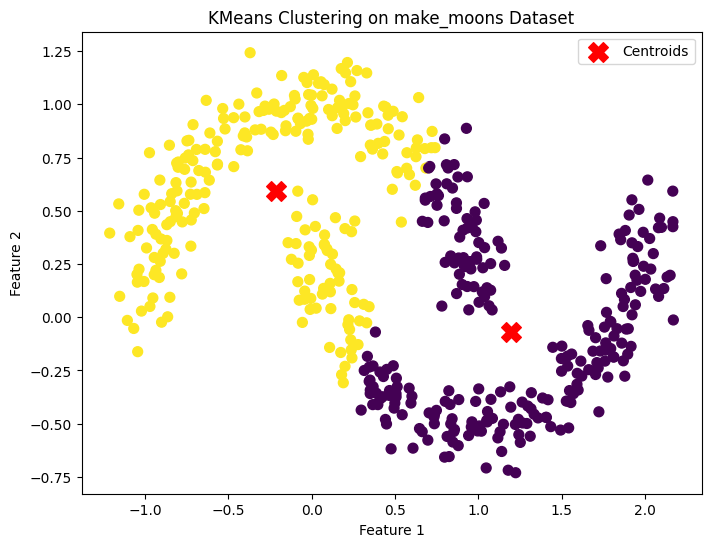

In [20]:
#Q.39)Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result
#Ans:-
# KMeans clustering on make_moons dataset

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Step 1: Generate synthetic non-linear dataset
X, y_true = make_moons(n_samples=500, noise=0.1, random_state=42)

# Step 2: Apply KMeans clustering (try 2 clusters for the two moons)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("KMeans Clustering on make_moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

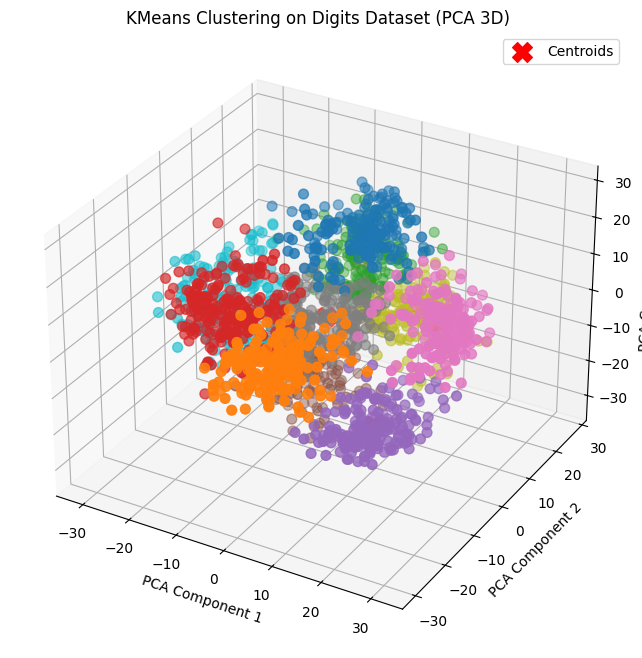

In [21]:
#Q.40)Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
#Ans:-
# KMeans clustering on Digits dataset with PCA (3D visualization)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Step 1: Load Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Reduce to 3 components using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Step 3: Apply KMeans clustering (10 clusters for digits 0–9)
kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit_predict(X_pca)

# Step 4: Visualization in 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=labels, cmap='tab10', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],
           c='red', s=200, marker='X', label='Centroids')

ax.set_title("KMeans Clustering on Digits Dataset (PCA 3D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.legend()
plt.show()

Silhouette Score for k=5: 0.678738720085253


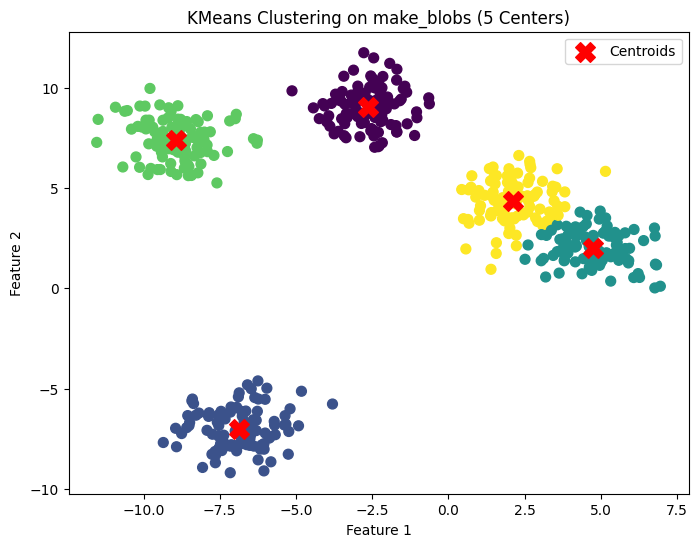

In [22]:
#Q.41)Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering
#Ans:-
# KMeans clustering with silhouette score on synthetic blobs

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 1: Generate synthetic dataset with 5 centers
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=1.0, random_state=42)

# Step 2: Apply KMeans clustering (k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Evaluate clustering with silhouette score
score = silhouette_score(X, labels)
print("Silhouette Score for k=5:", score)

# Step 4: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("KMeans Clustering on make_blobs (5 Centers)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

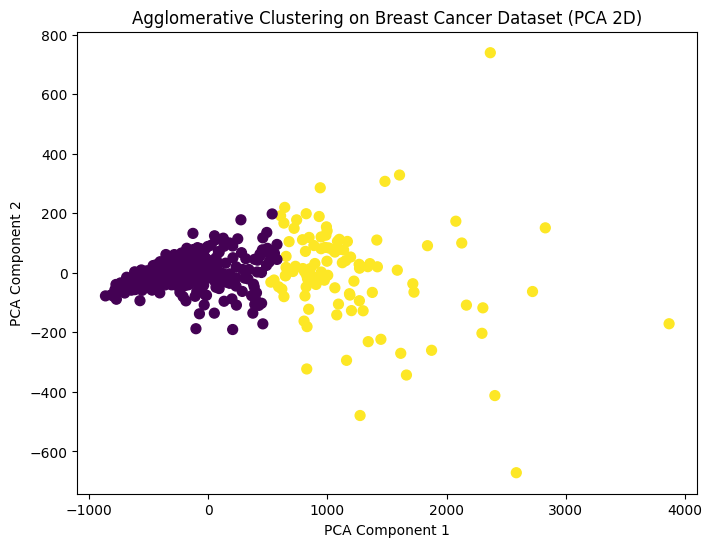

In [23]:
#Q.42)Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D
#Ans:-
# Agglomerative Clustering on Breast Cancer dataset with PCA visualization

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Step 2: Reduce dimensionality to 2 components using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Step 3: Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=2, linkage='ward')
labels = agg.fit_predict(X_pca)

# Step 4: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)

plt.title("Agglomerative Clustering on Breast Cancer Dataset (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

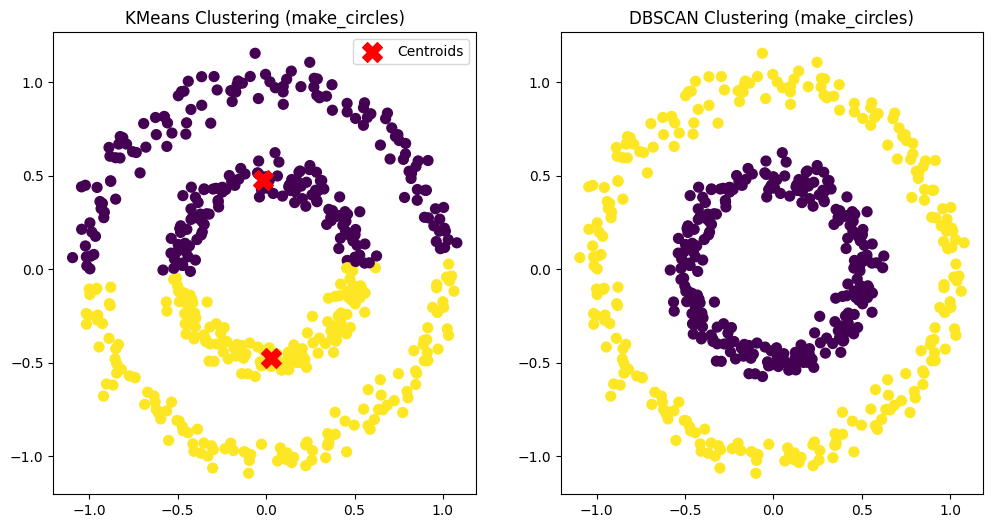

In [24]:
#Q.43)Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side
#Ans:-
# Compare KMeans vs DBSCAN on noisy circular data

import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

# Step 1: Generate noisy circular dataset
X, y_true = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Step 2: Apply KMeans clustering (2 clusters)
kmeans = KMeans(n_clusters=2, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

# Step 3: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan.fit_predict(X)

# Step 4: Visualization side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# KMeans plot
axes[0].scatter(X[:, 0], X[:, 1], c=labels_kmeans, cmap='viridis', s=50)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='red', s=200, marker='X', label='Centroids')
axes[0].set_title("KMeans Clustering (make_circles)")
axes[0].legend()

# DBSCAN plot
axes[1].scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap='viridis', s=50)
axes[1].set_title("DBSCAN Clustering (make_circles)")

plt.show()

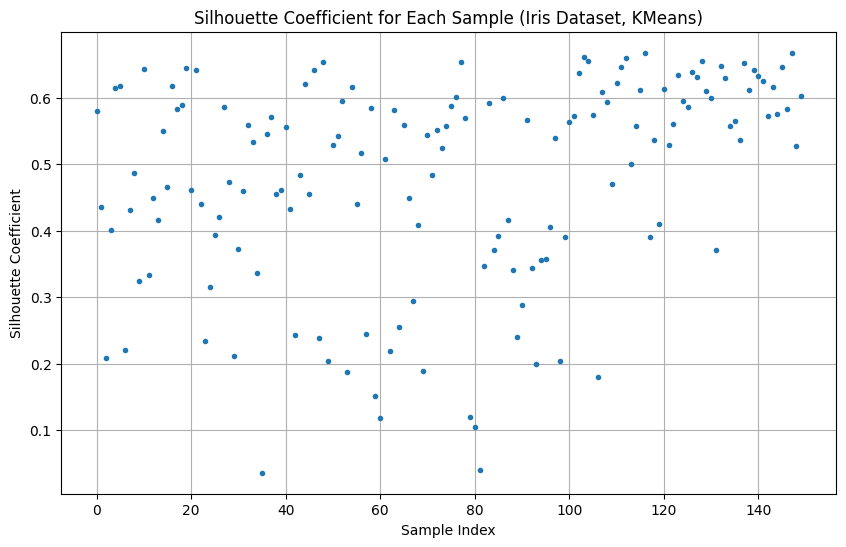

Average Silhouette Score: 0.4798814508199817


In [25]:
#Q.44)Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering
#Ans:-
# Silhouette Coefficient plot for Iris dataset after KMeans clustering

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import StandardScaler
import numpy as np

# Step 1: Load Iris dataset
iris = load_iris()
X = iris.data

# Step 2: Scale the data (optional but helps clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply KMeans clustering (3 clusters for Iris)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Step 4: Compute Silhouette Coefficient for each sample
silhouette_vals = silhouette_samples(X_scaled, labels)

# Step 5: Plot Silhouette Coefficient values
plt.figure(figsize=(10,6))
plt.plot(range(len(silhouette_vals)), silhouette_vals, marker='.', linestyle='None')
plt.title("Silhouette Coefficient for Each Sample (Iris Dataset, KMeans)")
plt.xlabel("Sample Index")
plt.ylabel("Silhouette Coefficient")
plt.grid(True)
plt.show()

# Step 6: Print average silhouette score
print("Average Silhouette Score:", np.mean(silhouette_vals))

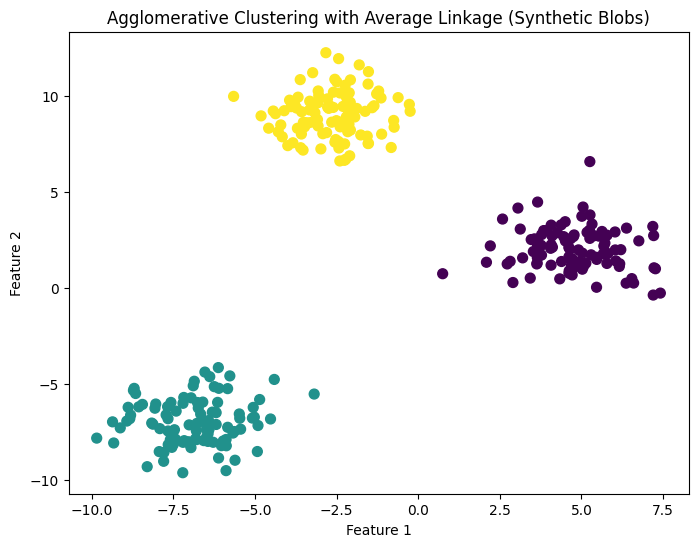

In [26]:
#Q.45)Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters
#Ans:-
# Agglomerative Clustering with average linkage on synthetic blobs

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# Step 1: Generate synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)

# Step 2: Apply Agglomerative Clustering with 'average' linkage
agg = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = agg.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)

plt.title("Agglomerative Clustering with Average Linkage (Synthetic Blobs)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

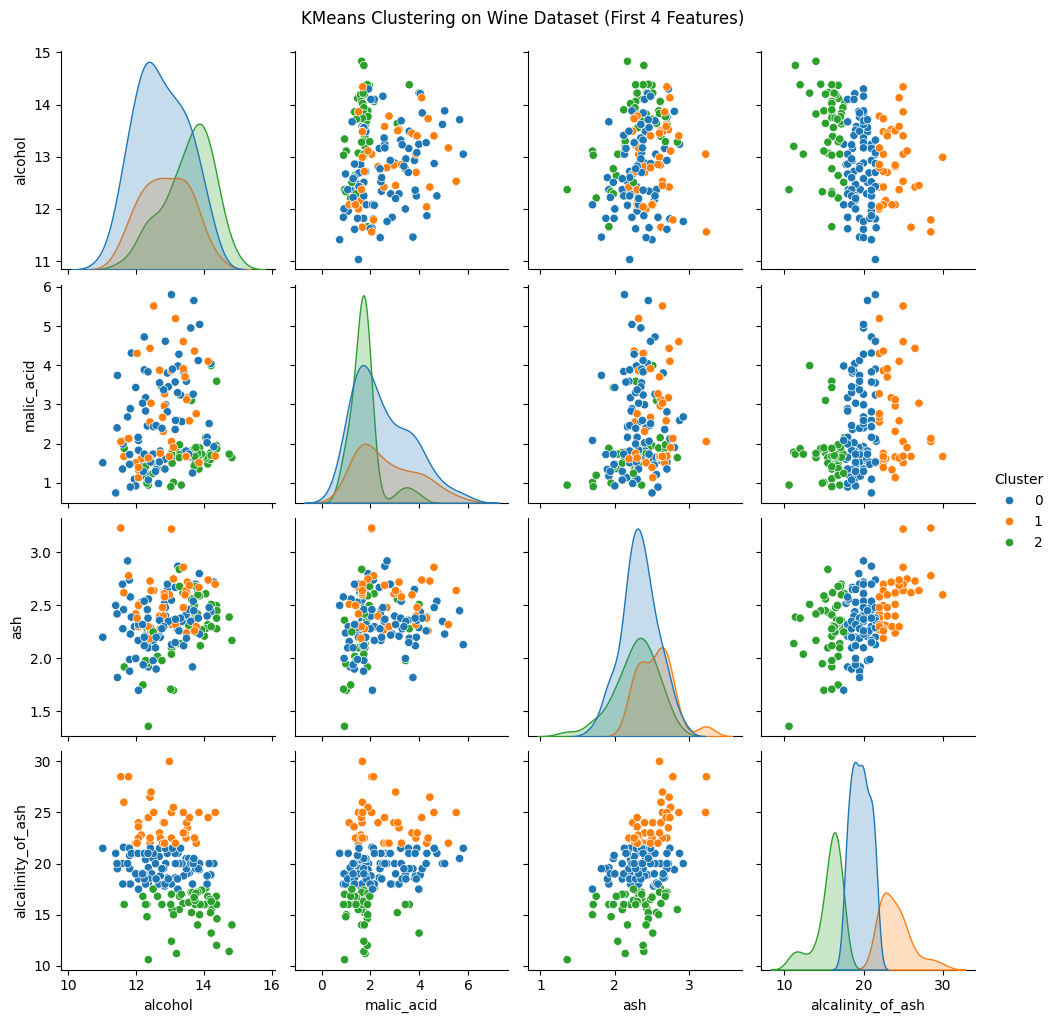

In [27]:
#Q.46)Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features)
#Ans:-
# KMeans clustering on Wine dataset with Seaborn pairplot

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data[:, :4]   # first 4 features
feature_names = wine.feature_names[:4]

# Step 2: Apply KMeans clustering (choose 3 clusters for Wine dataset)
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

# Step 3: Create DataFrame for visualization
df = pd.DataFrame(X, columns=feature_names)
df['Cluster'] = labels

# Step 4: Seaborn pairplot
sns.pairplot(df, vars=feature_names, hue='Cluster', palette='tab10', diag_kind='kde')
plt.suptitle("KMeans Clustering on Wine Dataset (First 4 Features)", y=1.02)
plt.show()

Number of clusters (excluding noise): 4
Number of noise points: 31


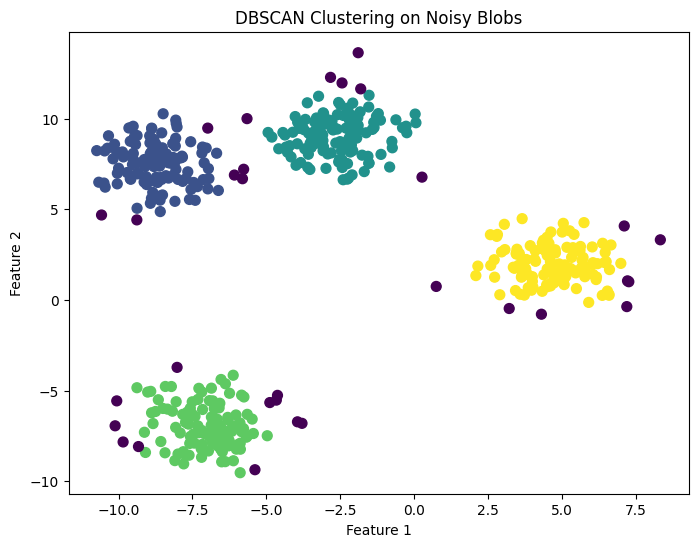

In [28]:
#Q.47)Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count
#Ans:-
# DBSCAN clustering on noisy blobs

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Generate noisy blobs dataset
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.2, random_state=42)

# Step 2: Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Count clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Number of clusters (excluding noise):", n_clusters)
print("Number of noise points:", n_noise)

# Step 4: Visualization
plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering on Noisy Blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

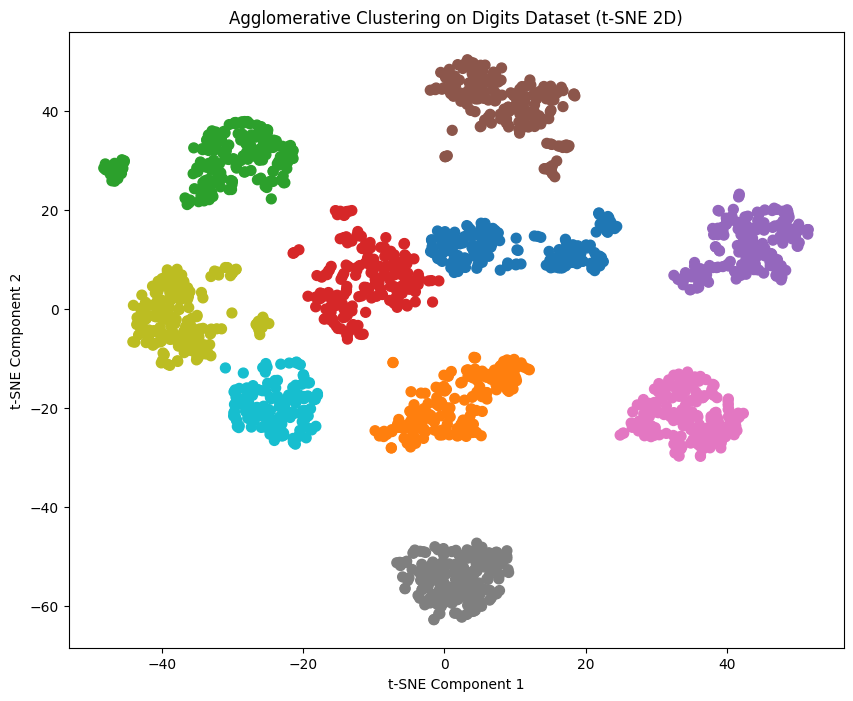

In [30]:
#Q.48)Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
#Ans:-
# Agglomerative Clustering on Digits dataset with t-SNE visualization

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Reduce dimensions using t-SNE (2D for visualization)
# Use max_iter instead of n_iter
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

# Step 3: Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = agg.fit_predict(X_tsne)

# Step 4: Visualization
plt.figure(figsize=(10,8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='tab10', s=50)
plt.title("Agglomerative Clustering on Digits Dataset (t-SNE 2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()